# Cluster Evaluation & Customer Profiling
## Customer Personality Analysis Dataset

**Module 07 — Machine Learning**

This notebook converts the K-Means clusters from Module 06 into meaningful,
business-actionable customer segments through demographic, spending, channel,
and campaign analysis, cluster naming, persona development, and final
visualization.


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
%matplotlib inline

df = pd.read_csv("00_Data/customer_segments_with_categories.csv")
CLUSTER_ORDER = sorted(df["Cluster"].unique())
palette = sns.color_palette("tab10", len(CLUSTER_ORDER))
CLUSTER_COLORS = {c: palette[i] for i, c in enumerate(CLUSTER_ORDER)}

SPEND_COLS = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
CHANNEL_COLS = ["NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumDealsPurchases"]
CAMPAIGN_COLS = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]

def cluster_label(c):
    return f"Cluster {c}: {df.loc[df['Cluster']==c, 'Segment_Name'].iloc[0]}"

df[["Cluster","Segment_Name"]].value_counts()

Cluster  Segment_Name                       
2        New / Developing Customers             676
1        Premium / Loyal Buyers                 639
3        High-Value Customers                   495
0        Discount Seekers / Budget Customers    427
Name: count, dtype: int64

## Activity 1 — Cluster Statistics & Demographic Analysis

In [2]:
demo_avg = df.groupby("Cluster")[["Customer_Age","Income","Family_Size","Total_Children"]].mean().round(1)
demo_avg["Size"] = df["Cluster"].value_counts().sort_index()
demo_avg

,Customer_Age,Income,Family_Size,Total_Children,Size
Cluster,,,,,
0,61.9,42574.2,3.7,2.0,427
1,60.8,59926.5,2.8,1.1,639
2,50.5,31890.6,2.4,0.8,676
3,57.1,76705.0,1.7,0.1,495


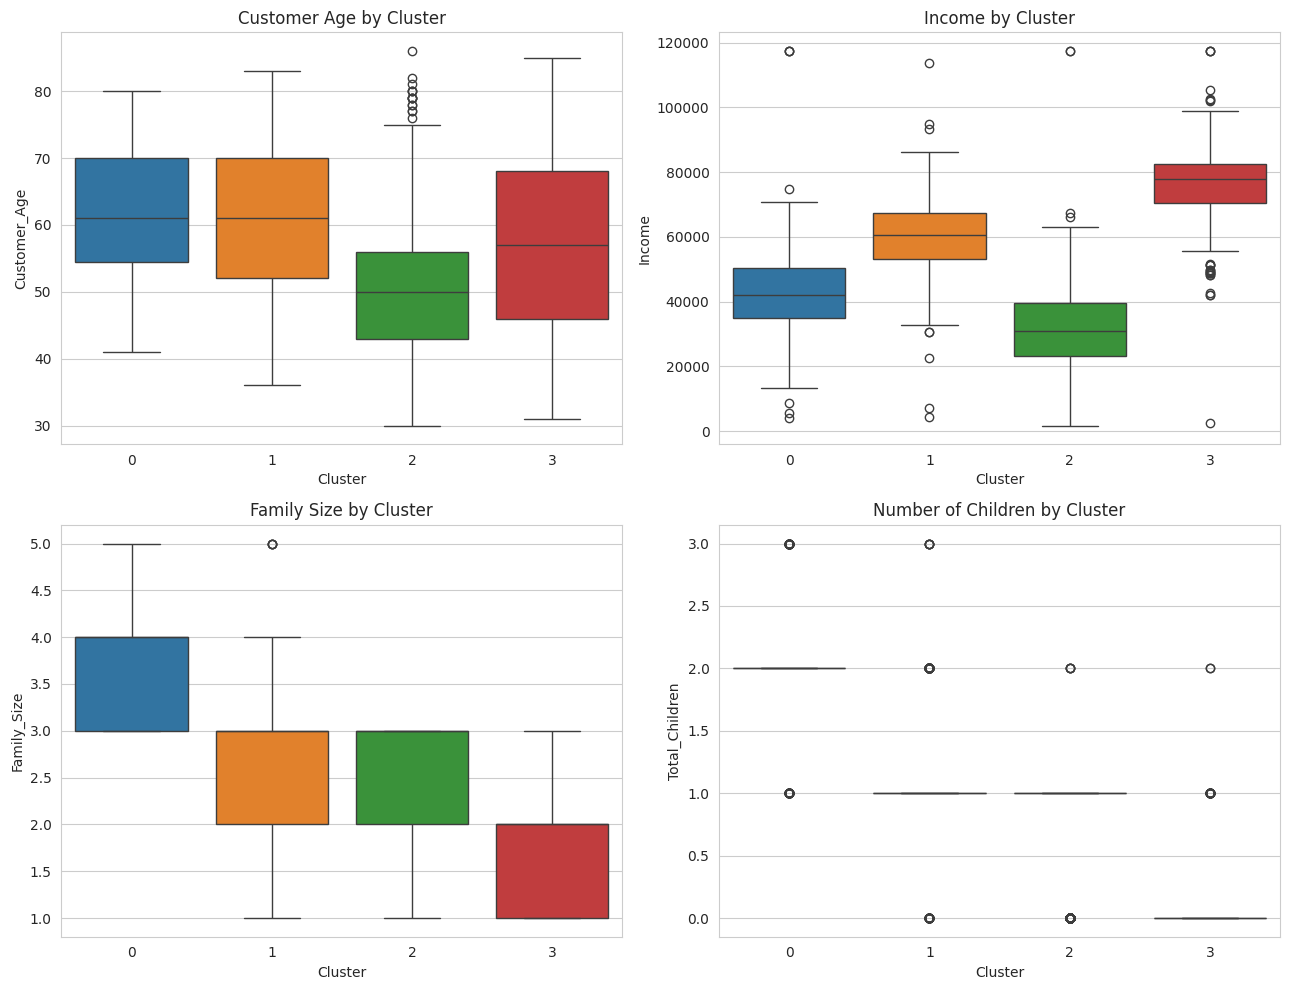

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13,10))
sns.boxplot(x="Cluster", y="Customer_Age", data=df, ax=axes[0,0], palette="tab10")
axes[0,0].set_title("Customer Age by Cluster")
sns.boxplot(x="Cluster", y="Income", data=df, ax=axes[0,1], palette="tab10")
axes[0,1].set_title("Income by Cluster")
sns.boxplot(x="Cluster", y="Family_Size", data=df, ax=axes[1,0], palette="tab10")
axes[1,0].set_title("Family Size by Cluster")
sns.boxplot(x="Cluster", y="Total_Children", data=df, ax=axes[1,1], palette="tab10")
axes[1,1].set_title("Number of Children by Cluster")
plt.tight_layout(); plt.show()

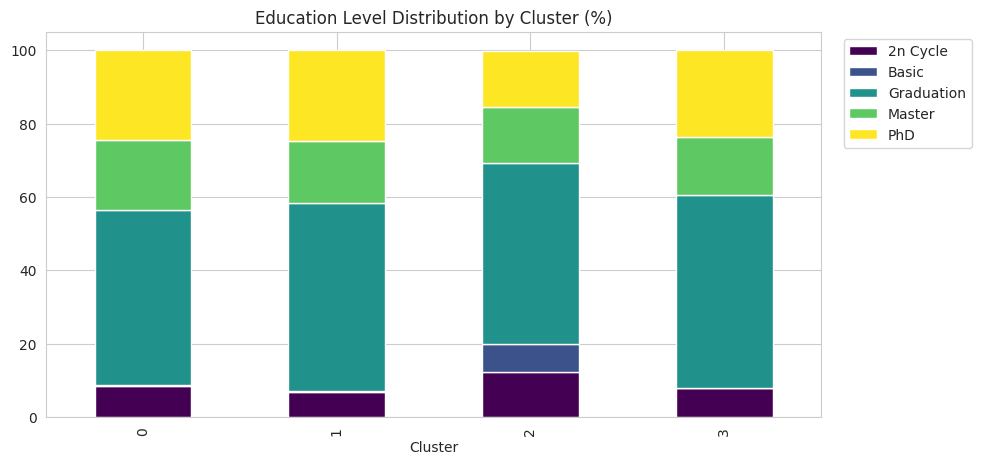

Education,2n Cycle,Basic,Graduation,Master,PhD
Cluster,,,,,
0,8.4,0.2,47.8,19.0,24.6
1,6.9,0.2,51.3,16.9,24.7
2,12.1,7.7,49.4,15.2,15.5
3,7.9,0.0,52.7,15.8,23.6


In [4]:
education_dist = pd.crosstab(df["Cluster"], df["Education"], normalize="index").round(3) * 100
marital_dist = pd.crosstab(df["Cluster"], df["Marital_Status"], normalize="index").round(3) * 100

education_dist.plot(kind="bar", stacked=True, figsize=(10,5), colormap="viridis")
plt.title("Education Level Distribution by Cluster (%)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.show()
education_dist

## Activity 2 — Spending Behavior Analysis

In [5]:
spend_avg = df.groupby("Cluster")[SPEND_COLS + ["Total_Spending"]].mean().round(1)
spend_avg

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending
Cluster,,,,,,,
0,74.7,4.0,27.3,5.9,3.9,15.5,131.3
1,468.8,33.5,164.4,44.9,35.7,66.7,814.0
2,36.9,6.7,27.2,9.8,6.8,17.5,104.9
3,653.8,62.8,481.3,93.1,63.7,75.3,1430.1


In [6]:
highest_spend = spend_avg["Total_Spending"].idxmax()
lowest_spend = spend_avg["Total_Spending"].idxmin()
premium_score = spend_avg["MntWines"].rank(pct=True) + spend_avg["MntGoldProds"].rank(pct=True)
premium_cluster = premium_score.idxmax()

print("Highest spending:", cluster_label(highest_spend))
print("Lowest spending:", cluster_label(lowest_spend))
print("Premium (Wine+Gold) buyers:", cluster_label(premium_cluster))

Highest spending: Cluster 3: High-Value Customers
Lowest spending: Cluster 2: New / Developing Customers
Premium (Wine+Gold) buyers: Cluster 3: High-Value Customers


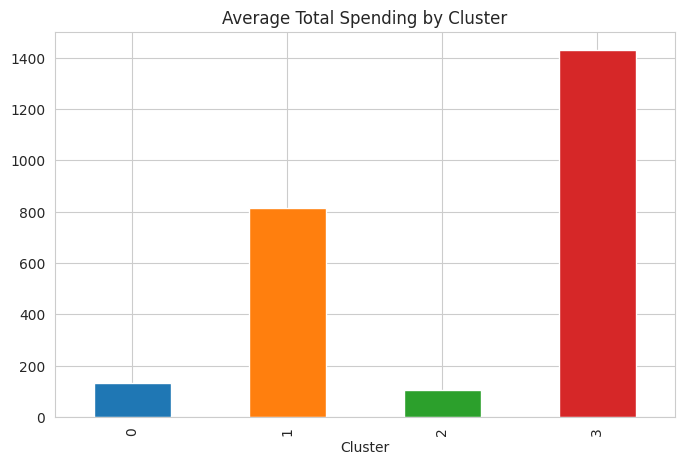

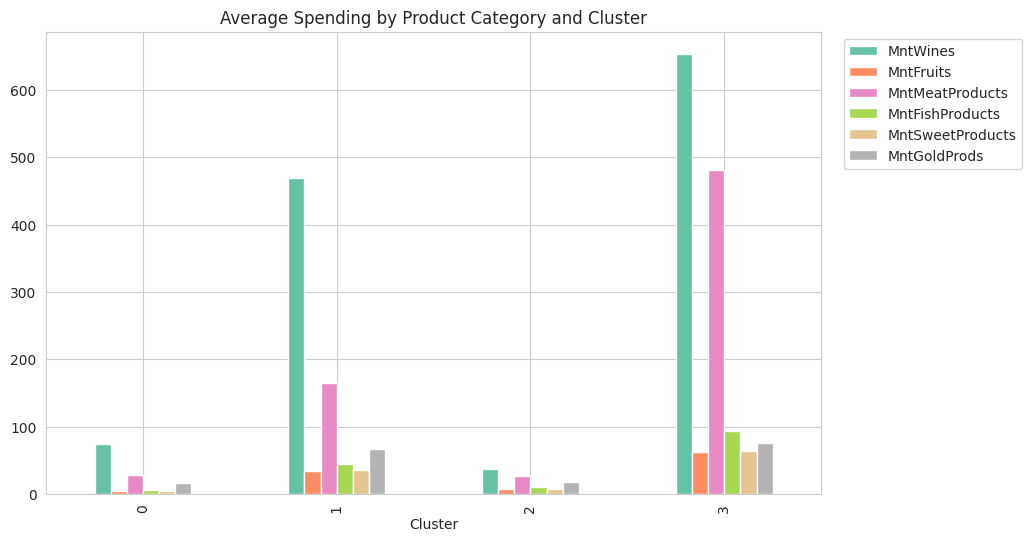

In [7]:
spend_avg["Total_Spending"].plot(kind="bar", figsize=(8,5), color=[CLUSTER_COLORS[c] for c in spend_avg.index])
plt.title("Average Total Spending by Cluster")
plt.show()

spend_avg[SPEND_COLS].plot(kind="bar", figsize=(10,6), colormap="Set2")
plt.title("Average Spending by Product Category and Cluster")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.show()

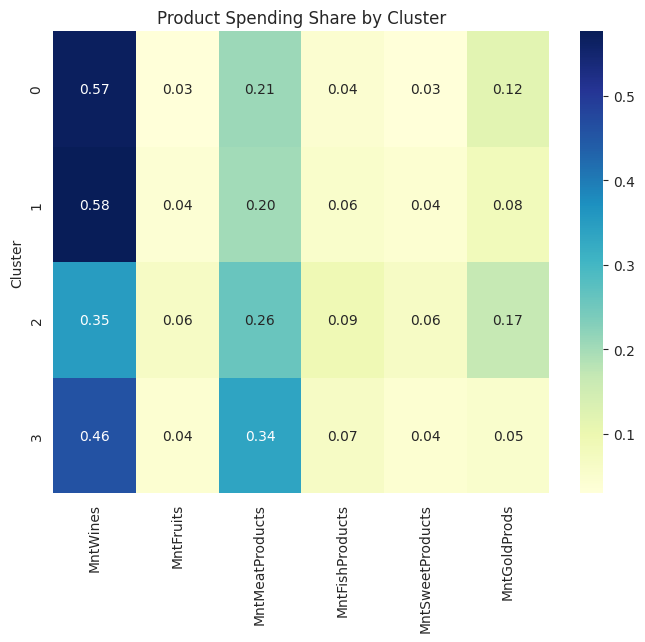

In [8]:
spend_share = spend_avg[SPEND_COLS].div(spend_avg[SPEND_COLS].sum(axis=1), axis=0)
plt.figure(figsize=(8,6))
sns.heatmap(spend_share, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Product Spending Share by Cluster")
plt.show()

## Activity 3 — Shopping Channel & Customer Engagement Analysis

In [9]:
channel_avg = df.groupby("Cluster")[CHANNEL_COLS + ["NumWebVisitsMonth","Recency"]].mean().round(1)
channel_avg

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,
0,2.4,0.8,3.5,2.8,6.2,50.2
1,6.7,3.4,8.2,3.5,5.5,47.7
2,2.1,0.6,3.2,1.8,6.5,49.0
3,4.8,6.3,8.2,1.2,2.7,50.1


In [10]:
print("Digital-First:", cluster_label(channel_avg['NumWebPurchases'].idxmax()))
print("Store-Oriented:", cluster_label(channel_avg['NumStorePurchases'].idxmax()))
print("Catalog-Oriented:", cluster_label(channel_avg['NumCatalogPurchases'].idxmax()))
print("Deal-Seeking:", cluster_label(channel_avg['NumDealsPurchases'].idxmax()))
print("Most Active (lowest Recency):", cluster_label(channel_avg['Recency'].idxmin()))
print("Least Active (highest Recency):", cluster_label(channel_avg['Recency'].idxmax()))

Digital-First: Cluster 1: Premium / Loyal Buyers
Store-Oriented: Cluster 1: Premium / Loyal Buyers
Catalog-Oriented: Cluster 3: High-Value Customers
Deal-Seeking: Cluster 1: Premium / Loyal Buyers
Most Active (lowest Recency): Cluster 1: Premium / Loyal Buyers
Least Active (highest Recency): Cluster 0: Discount Seekers / Budget Customers


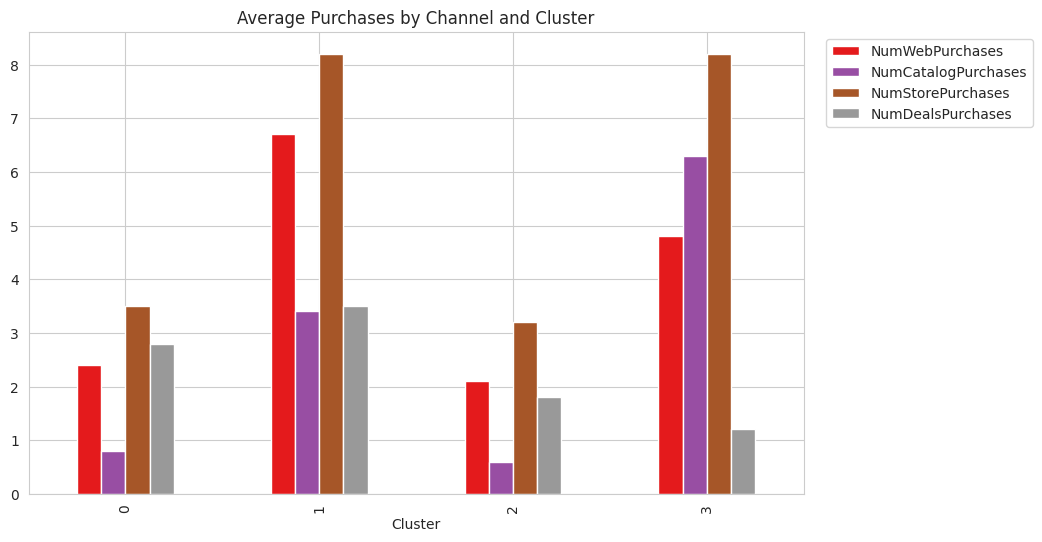

In [11]:
channel_avg[["NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumDealsPurchases"]].plot(
    kind="bar", figsize=(10,6), colormap="Set1")
plt.title("Average Purchases by Channel and Cluster")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.show()

## Activity 4 — Marketing Campaign Analysis

In [12]:
campaign_rates = (df.groupby("Cluster")[CAMPAIGN_COLS].mean() * 100).round(1)
campaign_rates["Complaint Rate (%)"] = (df.groupby("Cluster")["Complain"].mean() * 100).round(1)
campaign_rates

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Complaint Rate (%)
Cluster,,,,,,,
0,0.9,0.5,6.1,2.8,0.0,7.5,1.2
1,2.5,0.6,5.9,10.2,1.4,9.7,1.1
2,0.1,0.0,7.4,1.0,0.0,9.9,0.9
3,24.8,4.8,9.9,16.8,30.9,34.9,0.4


Most campaign-responsive: Cluster 3: High-Value Customers
Most marketing-resistant: Cluster 0: Discount Seekers / Budget Customers
Needs re-engagement (highest Recency): Cluster 0: Discount Seekers / Budget Customers


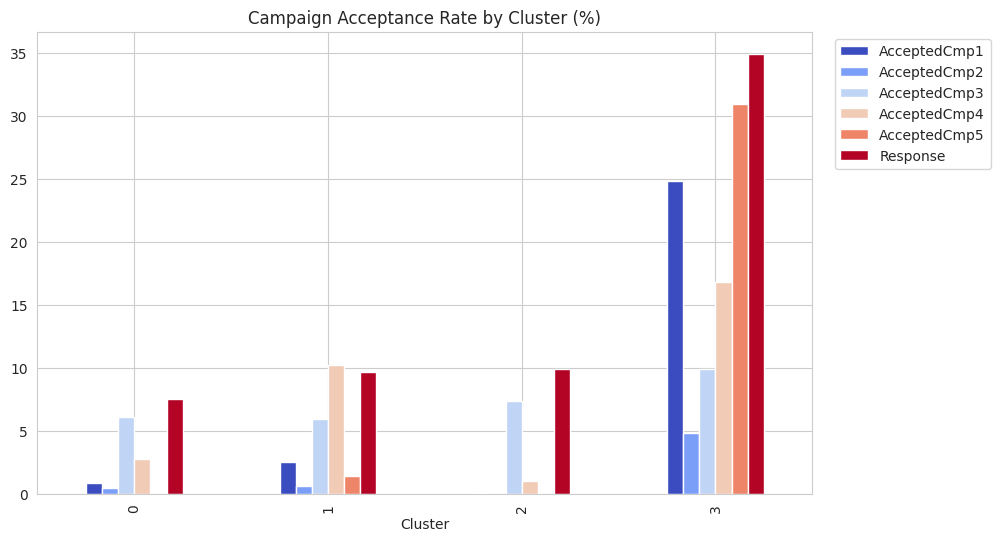

In [13]:
print("Most campaign-responsive:", cluster_label(campaign_rates['Response'].idxmax()))
print("Most marketing-resistant:", cluster_label(campaign_rates[CAMPAIGN_COLS].mean(axis=1).idxmin()))
print("Needs re-engagement (highest Recency):", cluster_label(df.groupby('Cluster')['Recency'].mean().idxmax()))

campaign_rates[CAMPAIGN_COLS].plot(kind="bar", figsize=(10,6), colormap="coolwarm")
plt.title("Campaign Acceptance Rate by Cluster (%)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.show()

## Activity 5 — Business Segmentation & Cluster Naming

| Cluster | Segment Name | Key Evidence |
|---|---|---|
| 3 | High-Value Customers | Highest income ($76,705), highest spend ($1,430), highest campaign acceptance (34.9%) |
| 1 | Premium / Loyal Buyers | Solid income ($59,927), strong spend ($814), most active across all channels |
| 0 | Discount Seekers / Budget Customers | Lower income ($42,574), lowest campaign responsiveness (7.5%), largest families |
| 2 | New / Developing Customers | Lowest income ($31,891) and spend ($105), youngest average age (50.5) |

**Note:** Recency is nearly flat across all four clusters (47.7–50.2 days), so
it is not a meaningful differentiator here — segment names are driven
primarily by income, spend, and campaign responsiveness rather than
activity recency.

## Activity 6 — Customer Persona Development

In [14]:
persona_names = {
    "High-Value Customers": "Victoria the Premium Patron",
    "Premium / Loyal Buyers": "Marcus the Multi-Channel Regular",
    "Discount Seekers / Budget Customers": "The Rodriguez Family (Budget-Conscious Household)",
    "New / Developing Customers": "Jamie the New Explorer",
}

for c in CLUSTER_ORDER:
    name = df.loc[df["Cluster"]==c, "Segment_Name"].iloc[0]
    print(f"--- {persona_names.get(name)} (Cluster {c}: {name}) ---")
    print(f"  Age: ~{demo_avg.loc[c,'Customer_Age']:.0f} yrs | Income: ${demo_avg.loc[c,'Income']:,.0f}")
    print(f"  Family size: {demo_avg.loc[c,'Family_Size']:.1f} | Total spend: ${spend_avg.loc[c,'Total_Spending']:,.0f}")
    print(f"  Campaign response: {campaign_rates.loc[c,'Response']:.1f}%")
    print()

--- The Rodriguez Family (Budget-Conscious Household) (Cluster 0: Discount Seekers / Budget Customers) ---
  Age: ~62 yrs | Income: $42,574
  Family size: 3.7 | Total spend: $131
  Campaign response: 7.5%

--- Marcus the Multi-Channel Regular (Cluster 1: Premium / Loyal Buyers) ---
  Age: ~61 yrs | Income: $59,926
  Family size: 2.8 | Total spend: $814
  Campaign response: 9.7%

--- Jamie the New Explorer (Cluster 2: New / Developing Customers) ---
  Age: ~50 yrs | Income: $31,891
  Family size: 2.4 | Total spend: $105
  Campaign response: 9.9%

--- Victoria the Premium Patron (Cluster 3: High-Value Customers) ---
  Age: ~57 yrs | Income: $76,705
  Family size: 1.7 | Total spend: $1,430
  Campaign response: 34.9%



## Activity 7 — Cluster Visualization & Final Documentation

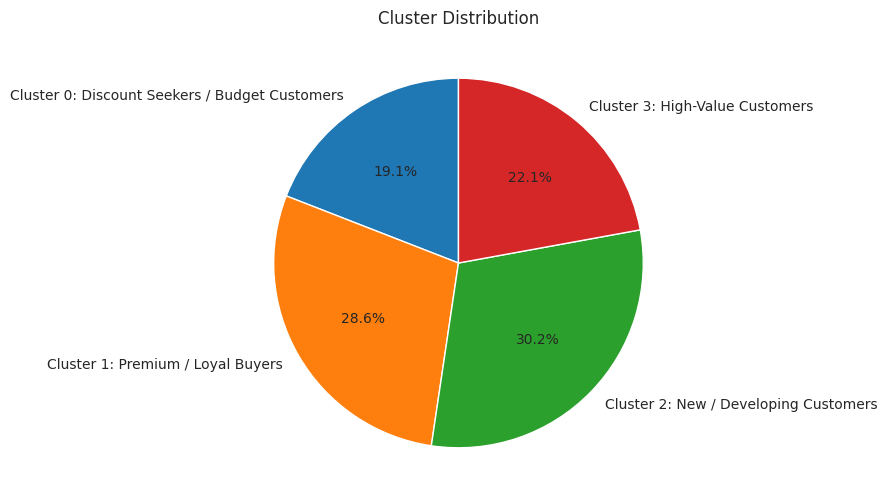

In [15]:
sizes = df["Cluster"].value_counts().sort_index()
plt.figure(figsize=(7,6))
plt.pie(sizes, labels=[cluster_label(c) for c in sizes.index], autopct="%1.1f%%",
        colors=[CLUSTER_COLORS[c] for c in sizes.index], startangle=90)
plt.title("Cluster Distribution")
plt.show()

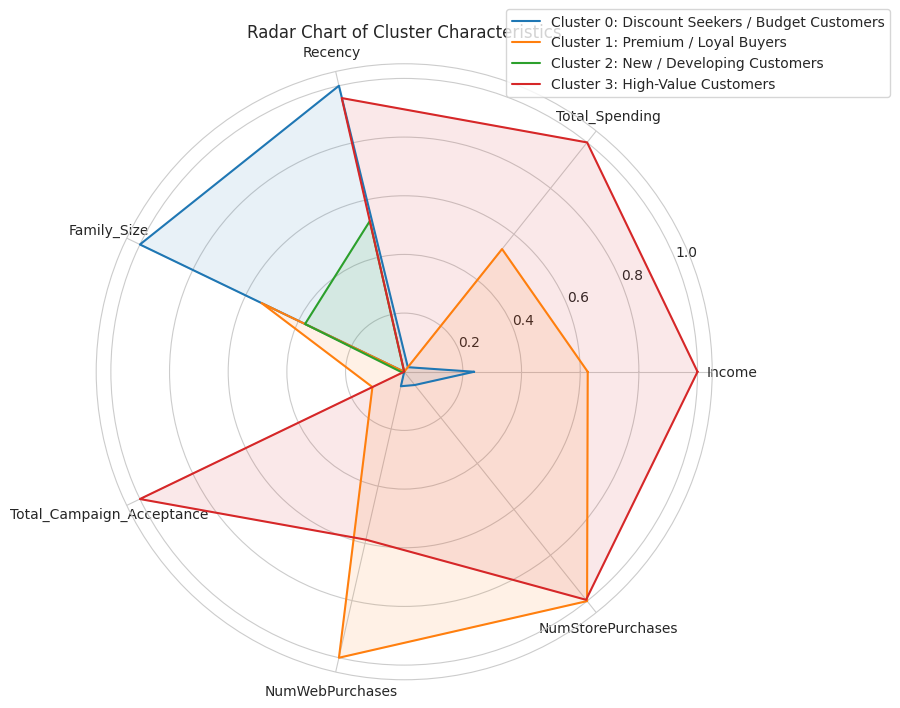

In [16]:
radar_cols = ["Income","Total_Spending","Recency","Family_Size","Total_Campaign_Acceptance","NumWebPurchases","NumStorePurchases"]
radar_source = df.groupby("Cluster")[radar_cols].mean()
radar_norm = (radar_source - radar_source.min()) / (radar_source.max() - radar_source.min() + 1e-9)
angles = np.linspace(0, 2*np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for c in radar_norm.index:
    values = radar_norm.loc[c].tolist(); values += values[:1]
    ax.plot(angles, values, label=cluster_label(c), color=CLUSTER_COLORS[c])
    ax.fill(angles, values, alpha=0.1, color=CLUSTER_COLORS[c])
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_cols)
ax.set_title("Radar Chart of Cluster Characteristics")
ax.legend(bbox_to_anchor=(1.3,1.1))
plt.show()

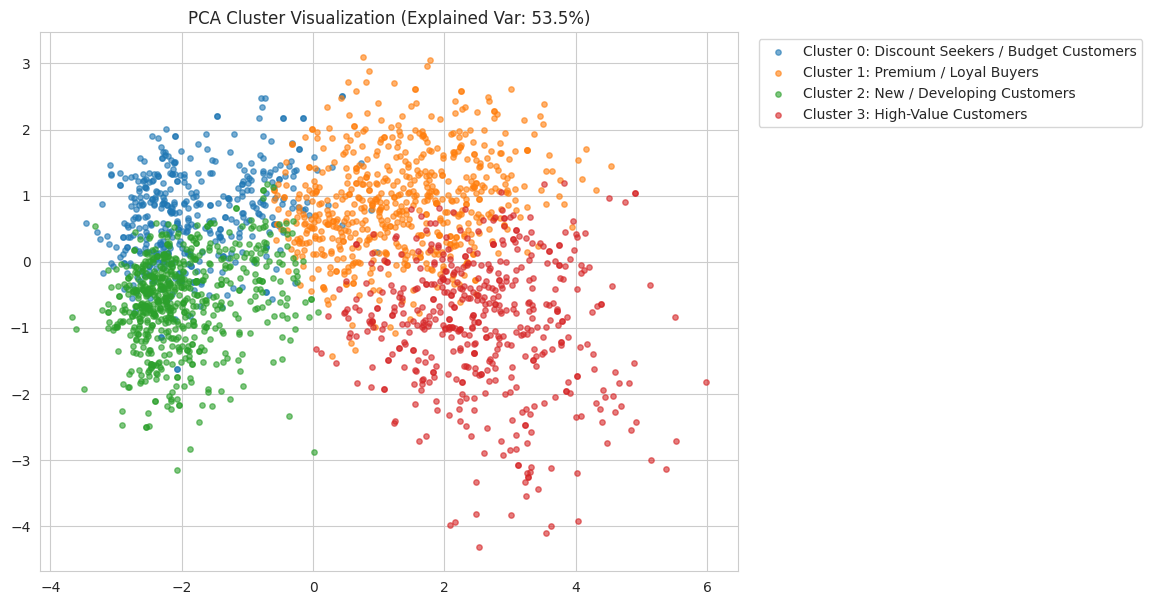

In [17]:
numeric_features = ["Customer_Age","Income","Total_Spending","Recency","Customer_Tenure","Family_Size",
                     "Total_Purchases","Total_Campaign_Acceptance","NumWebPurchases","NumStorePurchases","NumCatalogPurchases"]
X = df[numeric_features].copy()
X = (X - X.mean()) / X.std()
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

plt.figure(figsize=(9,7))
for c in CLUSTER_ORDER:
    mask = df["Cluster"] == c
    plt.scatter(coords[mask,0], coords[mask,1], alpha=0.6, s=15, color=CLUSTER_COLORS[c], label=cluster_label(c))
plt.title(f"PCA Cluster Visualization (Explained Var: {pca.explained_variance_ratio_.sum()*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.show()

In [18]:
FINAL = Path("04_Final_Deliverables")
FINAL.mkdir(exist_ok=True)
df.to_csv(FINAL / "customer_profiles_final.csv", index=False)
print("Final profiled dataset saved:", df.shape)

Final profiled dataset saved: (2237, 67)


## Summary

Four K-Means clusters were converted into named, business-actionable customer
segments — **High-Value Customers**, **Premium/Loyal Buyers**, **Discount
Seekers/Budget Customers**, and **New/Developing Customers** — each with a
documented profile, justification, persona, and recommended marketing
strategy, ready to guide targeted campaigns and retention efforts.